In [1]:
### Import Required Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/online_retail.csv")

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [11]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-12-10 12:50:00


In [12]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [29]:
rfm.columns = ['Recency','Frequency','Monetary','Cluster','Segment']

In [13]:
### Standardize RFM Data
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled[:5])

[[ 2.32202285 -0.32936215 -0.23100099]
 [-0.89373323  0.20610242  0.29343167]
 [-0.1691956  -0.11517632 -0.01231622]
 [-0.72500529 -0.43645506 -0.01714563]
 [ 2.16322008 -0.43645506 -0.19031183]]


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled[:5])

[[ 2.32202285 -0.32936215 -0.23100099]
 [-0.89373323  0.20610242  0.29343167]
 [-0.1691956  -0.11517632 -0.01231622]
 [-0.72500529 -0.43645506 -0.01714563]
 [ 2.16322008 -0.43645506 -0.19031183]]


In [15]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

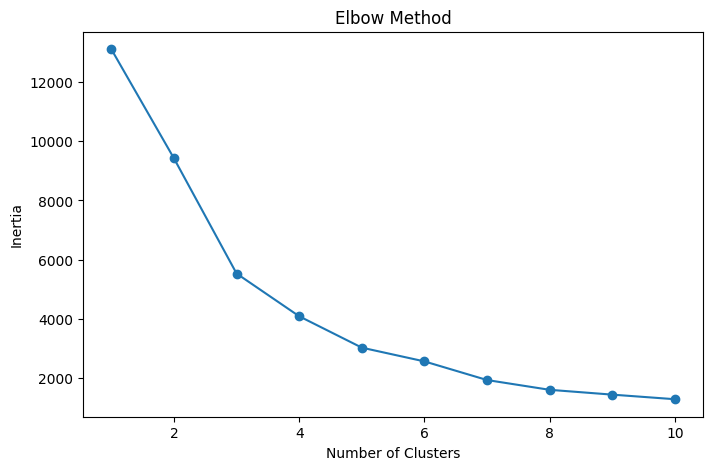

In [16]:
### Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [17]:
### Train KMeans Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [18]:
rfm.head()

,InvoiceDate,InvoiceNo,TotalAmount,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [19]:
rfm['Cluster'].value_counts()

Cluster
3    3090
1    1077
0     194
2      11
Name: count, dtype: int64

In [20]:
cluster_summary = rfm.groupby('Cluster').mean()

print(cluster_summary)

         InvoiceDate   InvoiceNo    TotalAmount
Cluster                                        
0          10.752577   28.510309   12168.264691
1         248.927577    1.805942     455.110716
2           5.090909  109.909091  124312.306364
3          42.780906    4.370550    1320.981506


In [21]:
segment_map = {
    0:'High Value',
    1:'Regular',
    2:'Occasional',
    3:'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [22]:
rfm.head()

,InvoiceDate,InvoiceNo,TotalAmount,Cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,Regular
12347.0,2,7,4310.00,3,At Risk
12348.0,75,4,1797.24,3,At Risk
12349.0,19,1,1757.55,3,At Risk
12350.0,310,1,334.40,1,Regular


In [27]:
print(rfm.columns)

Index(['InvoiceDate', 'InvoiceNo', 'TotalAmount', 'Cluster', 'Segment'], dtype='object')


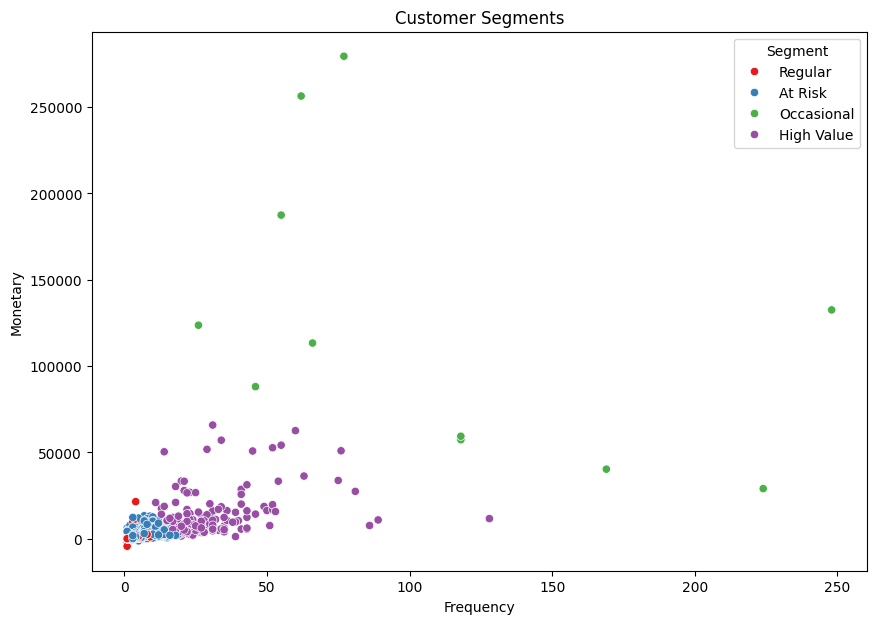

In [30]:
### Cluster Scatter Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

In [31]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,Regular
12347.0,2,7,4310.00,3,At Risk
12348.0,75,4,1797.24,3,At Risk
12349.0,19,1,1757.55,3,At Risk
12350.0,310,1,334.40,1,Regular


In [32]:
print(rfm['Cluster'].value_counts())

Cluster
3    3090
1    1077
0     194
2      11
Name: count, dtype: int64


In [34]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_summary)

            Recency   Frequency       Monetary
Cluster                                       
0         10.752577   28.510309   12168.264691
1        248.927577    1.805942     455.110716
2          5.090909  109.909091  124312.306364
3         42.780906    4.370550    1320.981506


In [35]:
segment_map = {
    0:'High Value',
    1:'Regular',
    2:'Occasional',
    3:'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,Regular
12347.0,2,7,4310.00,3,At Risk
12348.0,75,4,1797.24,3,At Risk
12349.0,19,1,1757.55,3,At Risk
12350.0,310,1,334.40,1,Regular


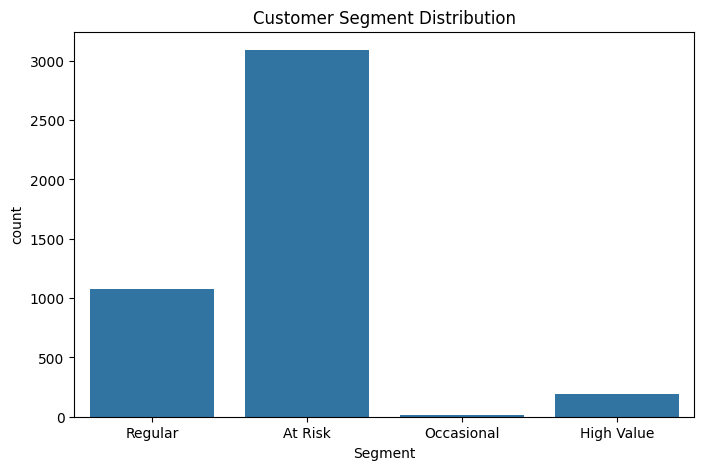

In [37]:
### Cluster Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=rfm
)

plt.title('Customer Segment Distribution')

plt.show()

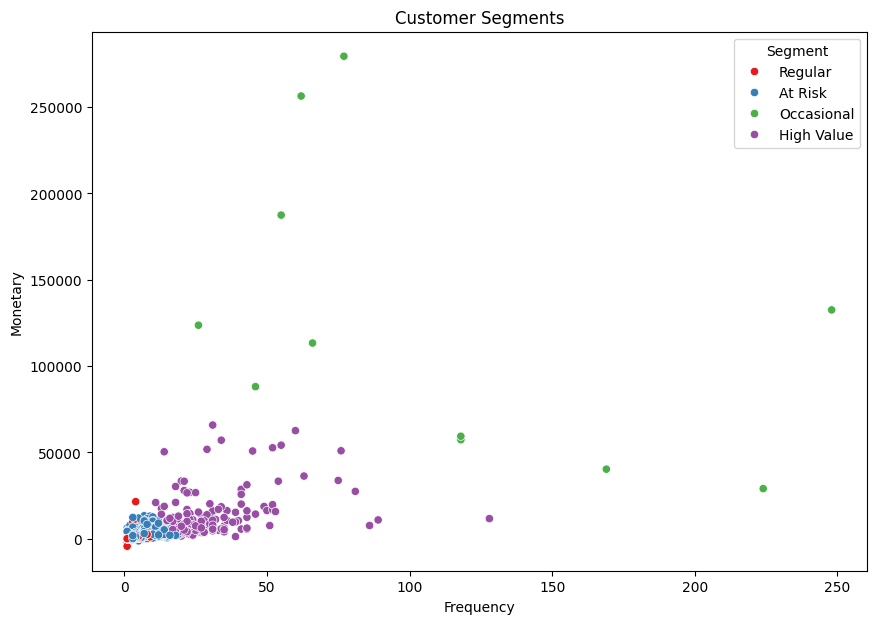

In [38]:
### Frequency vs Monetary Scatter Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Segment',
    data=rfm,
    palette='Set1'
)

plt.title('Customer Segments')

plt.show()

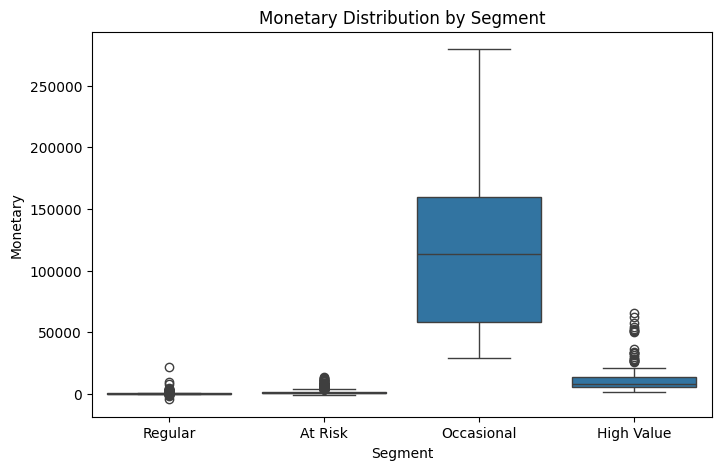

In [39]:
### Boxplot of Monetary Value
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Segment',
    y='Monetary',
    data=rfm
)

plt.title('Monetary Distribution by Segment')

plt.show()

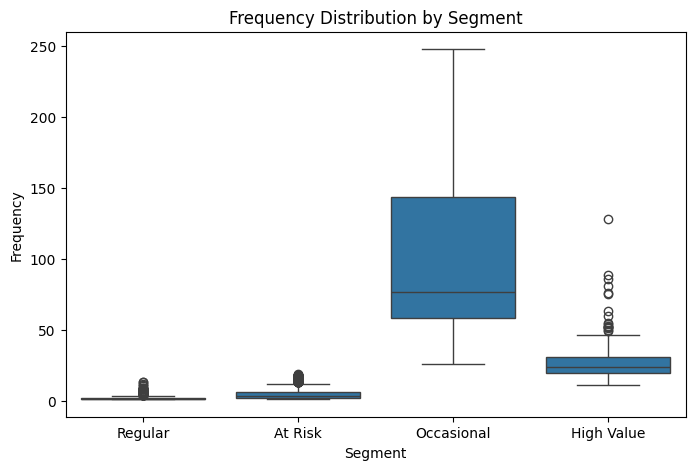

In [40]:
### Boxplot of Frequency
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Segment',
    y='Frequency',
    data=rfm
)

plt.title('Frequency Distribution by Segment')

plt.show()

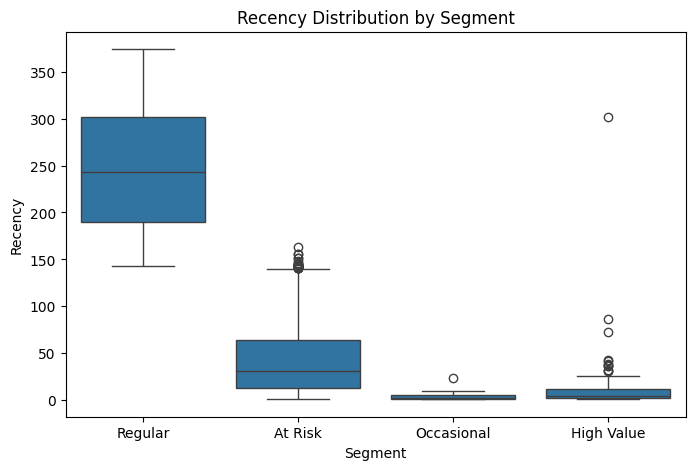

In [41]:
### Boxplot of Recency
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Segment',
    y='Recency',
    data=rfm
)

plt.title('Recency Distribution by Segment')

plt.show()

In [42]:
### Silhouette Score
score = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print("Silhouette Score =",score)

Silhouette Score = 0.6142804196098184


In [43]:
### Save KMeans Model
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [44]:
### Save StandardScaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [45]:
### Save Customer Segments
rfm.to_csv(
    "../models/customer_segments.csv",
    index=False
)

In [46]:
### Cluster Profile Table
cluster_profile = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

print(cluster_profile)

               Recency   Frequency       Monetary
Segment                                          
At Risk      42.780906    4.370550    1320.981506
High Value   10.752577   28.510309   12168.264691
Occasional    5.090909  109.909091  124312.306364
Regular     248.927577    1.805942     455.110716


In [47]:
### Customer-Product Matrix
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
### Import Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

In [49]:
### Transpose Matrix
product_matrix = customer_product_matrix.T

In [50]:
### Compute Similarity Matrix
similarity = cosine_similarity(product_matrix)

In [51]:
### Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)

In [52]:
### Check Similarity Matrix
similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000000,0.000494,0.000000,0.000000,0.031809,0.000000,0.000272,0.134904,...,0.0,0.002012,0.028772,0.002469,0.0,0.006003,0.0,0.039492,0.00000,0.001852
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.009132,0.004512,0.000000,0.020511,0.016846,0.919223,0.145911,0.008435,...,0.0,0.001864,0.021638,0.011984,0.0,0.015008,0.0,0.010457,0.00000,0.031389
DOLLY GIRL BEAKER,0.000000,0.009132,1.000000,0.536503,0.728954,0.017901,0.005123,0.007489,0.002646,0.187001,...,0.0,0.000174,0.009874,0.369115,0.0,0.252355,0.0,0.456007,0.00036,0.015570
I LOVE LONDON MINI BACKPACK,0.000494,0.004512,0.536503,1.000000,0.705221,0.025421,0.001174,0.004645,0.007067,0.172442,...,0.0,0.001621,0.008344,0.354292,0.0,0.239958,0.0,0.454081,0.00000,0.016661
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.728954,0.705221,1.000000,0.000000,0.000000,0.000000,0.000000,0.214024,...,0.0,0.000000,0.000000,0.492357,0.0,0.331059,0.0,0.616895,0.00000,0.000000


In [53]:
### Recommendation Function
def recommend_products(product_name):

    if product_name not in similarity_df.columns:
        return ["Product not found"]

    similar_scores = similarity_df[product_name]

    recommendations = (
        similar_scores
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
        .tolist()
    )

    return recommendations

In [54]:
### Test Recommendation
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

['GIN + TONIC DIET METAL SIGN',
 'TEA TIME TEA TOWELS ',
 'FAIRY CAKE FLANNEL ASSORTED COLOUR',
 'RED HANGING HEART T-LIGHT HOLDER',
 'DOORMAT FAIRY CAKE']

In [55]:
### Try Another Product
recommend_products("JUMBO BAG RED RETROSPOT")

['JUMBO BAG PINK POLKADOT',
 'JUMBO BAG APPLES',
 'JUMBO BAG STRAWBERRY',
 'JUMBO BAG PINK VINTAGE PAISLEY',
 'JUMBO  BAG BAROQUE BLACK WHITE']

In [56]:
### Save Similarity Matrix
import joblib

joblib.dump(
    similarity_df,
    "../models/similarity_matrix.pkl"
)

['../models/similarity_matrix.pkl']

In [57]:
### Save Product List
joblib.dump(
    similarity_df.columns.tolist(),
    "../models/product_names.pkl"
)

['../models/product_names.pkl']

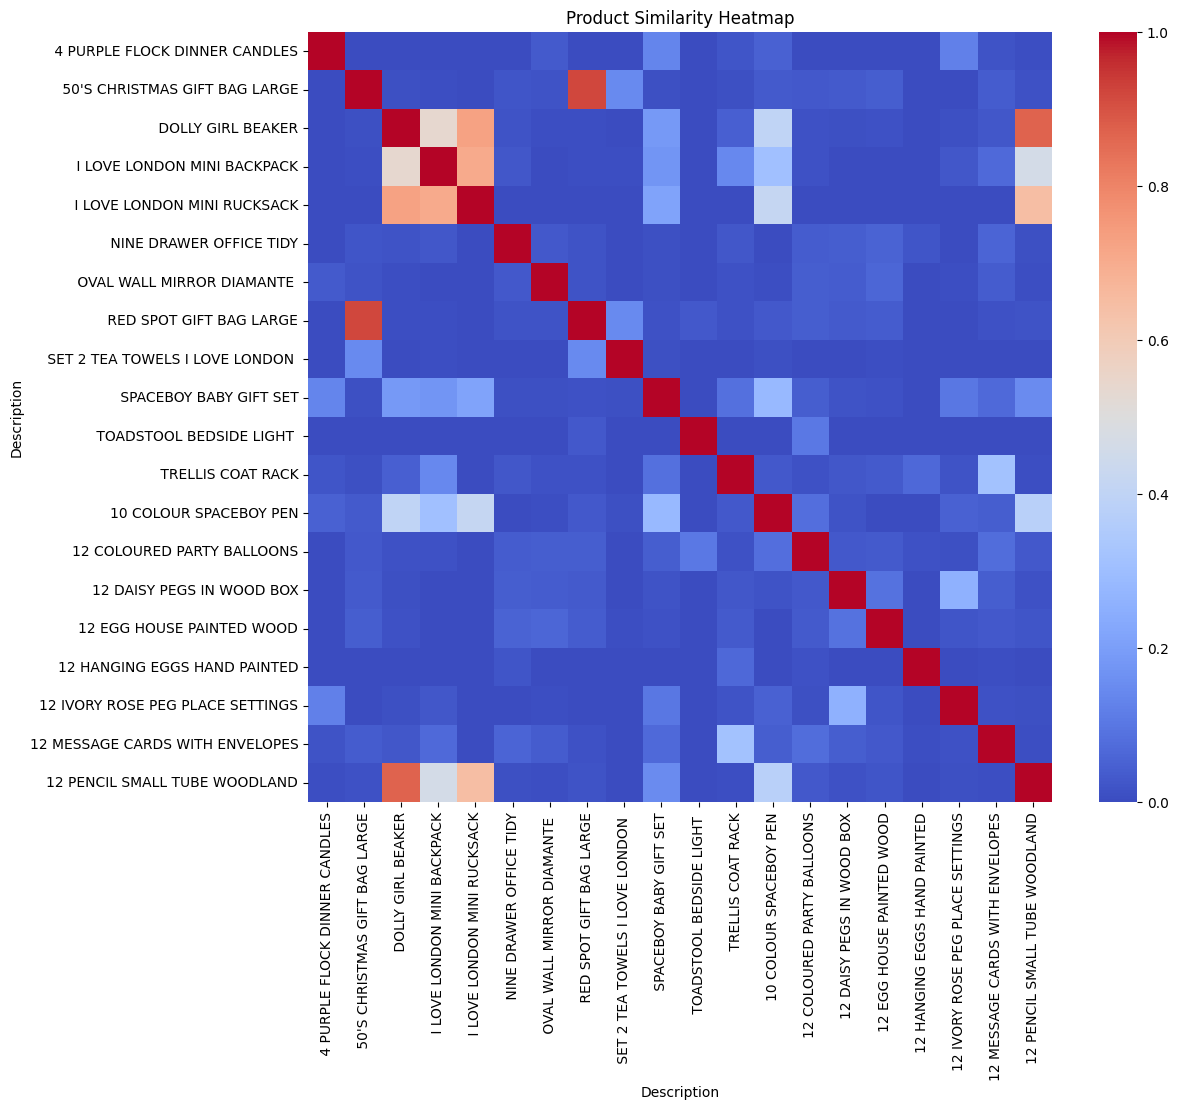

In [59]:
### Visualization 1: Heatmap of Similarity Matrix

subset = similarity_df.iloc[:20,:20]

plt.figure(figsize=(12,10))

sns.heatmap(
    subset,
    cmap='coolwarm'
)

plt.title("Product Similarity Heatmap")

plt.show()

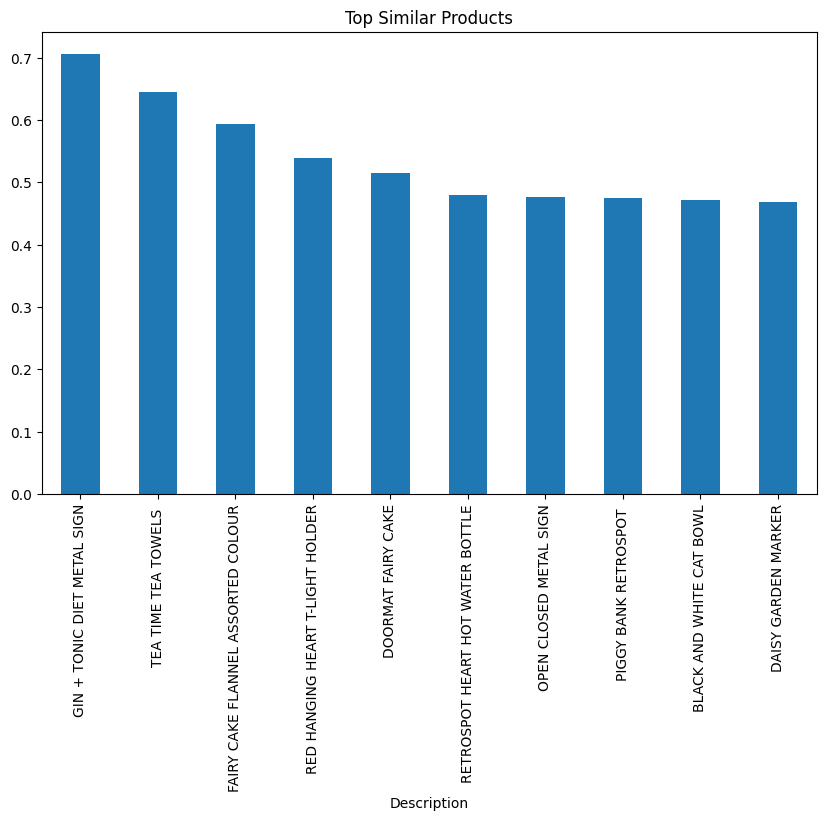

In [60]:
### Visualization 2: Top Similar Products
product = "WHITE HANGING HEART T-LIGHT HOLDER"

top_similar = (
    similarity_df[product]
    .sort_values(ascending=False)
    .iloc[1:11]
)

plt.figure(figsize=(10,6))

top_similar.plot(kind='bar')

plt.title("Top Similar Products")

plt.show()

In [62]:
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

In [63]:
joblib.dump(kmeans, "models/kmeans_model.pkl")

joblib.dump(scaler, "models/scaler.pkl")

joblib.dump(similarity_df, "models/similarity_matrix.pkl")

['models/similarity_matrix.pkl']

In [64]:
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(similarity_df, "models/similarity_matrix.pkl")

['models/similarity_matrix.pkl']

In [ ]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(similarity_df, "models/similarity_matrix.pkl")

print("Models saved successfully!")